In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc)

In [7]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [10]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,
#stratify=y)

In [11]:
scaler=StandardScaler()

X_train =scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

In [14]:
mle_model =LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42)
mle_model.fit(X_train,y_train)
y_pred_mle=mle_model.predict(X_test)

In [17]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42)
map_l2.fit(X_train,y_train)

y_pred_l2 = map_l2.predict(X_test)

In [19]:
map_l1=LogisticRegression(
     penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42)
map_l1.fit(X_train,y_train)
y_pred_l1 = map_l1.predict(X_test)
    

In [21]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)
    print("Accuracy:",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1 Sore:",f1_score(y_true,y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))
    

In [23]:
evaluate("MLE", y_test,y_pred_mle)
evaluate("MAP(L2)", y_test,y_pred_l2)
evaluate("MAP(L1)", y_test,y_pred_l1)


MLE
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Sore: 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Sore: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 Sore: 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [28]:
print("number of zero coeifficient")
print("MLE:",np.sum(mle_model.coef_[0]==0))
print("MAP(L2)",np.sum(map_l2.coef_[0]==0))
print("MAP(L1)",np.sum(map_l1.coef_[0]==0))

number of zero coeifficient
MLE: 0
MAP(L2) 0
MAP(L1) 14


In [33]:
results=pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1 Sore"])
models = [
("MLE", mle_model, y_pred_mle),
("MAP L2", map_l2, y_pred_l2),
("MAP L1", map_l1, y_pred_l1)]

for name, model, pred in models:
    results.loc[len(results)]=[name,accuracy_score(y_test,pred),
    precision_score(y_test,pred),
    recall_score(y_test,pred),
    f1_score(y_test,pred)]
    
print(results)

    Model  Accuracy  Precision    Recall   F1 Sore
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


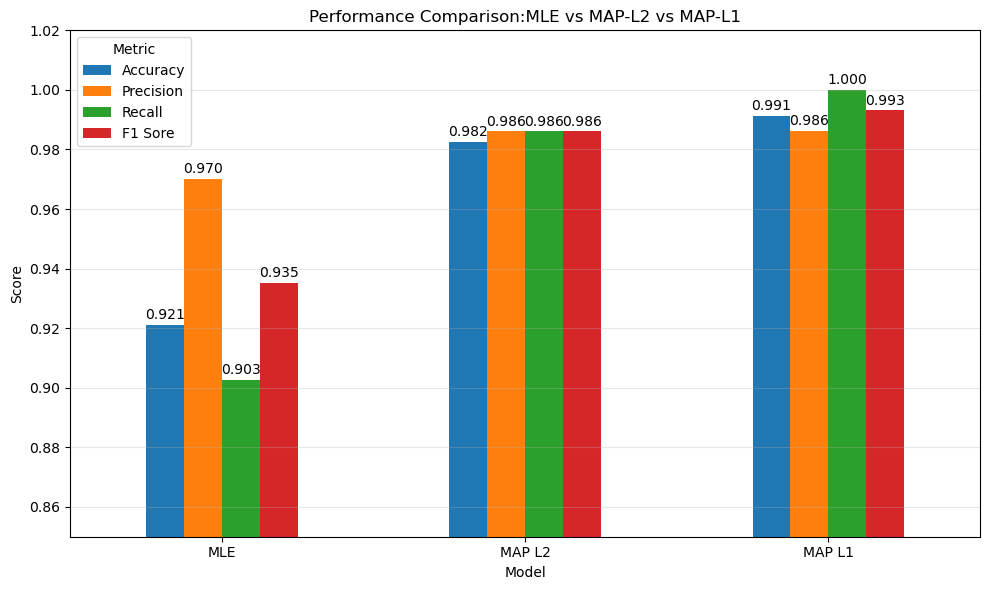

In [47]:
ax = results.set_index("Model").plot(kind="bar",figsize=(10, 6))
plt.title("Performance Comparison:MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

# show values on bars
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()
    

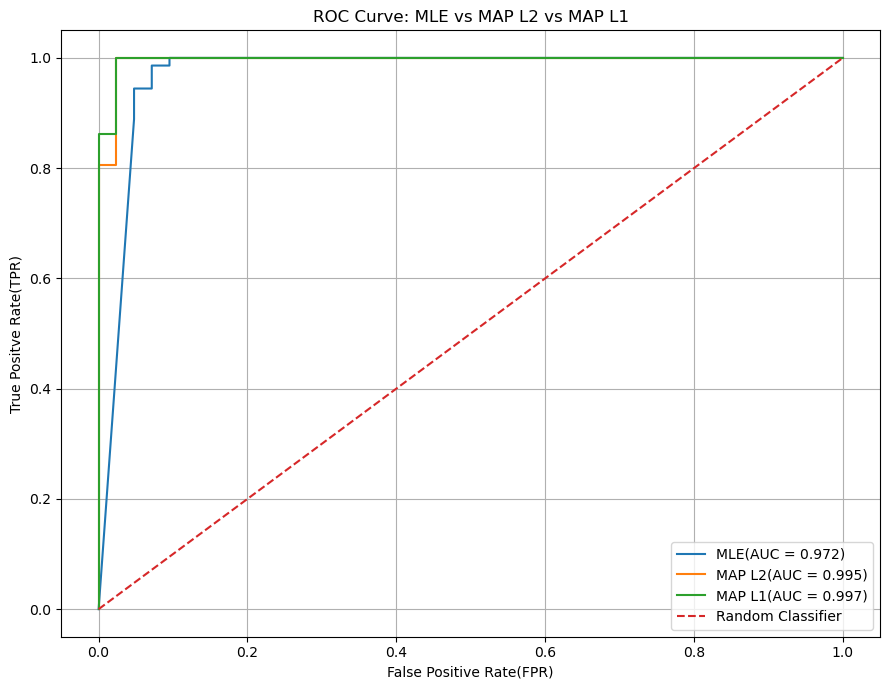

In [54]:
plt.figure(figsize=(9, 7))
for name,model,pred in models:
    # predicted probabilty for positive class
    y_prob=model.predict_proba(X_test)[:,1]
    #calculated ROC values
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    #calculate AUC
    roc_auc=auc(fpr,tpr)
    #plot ROC curve
    plt.plot(fpr,tpr,label=f"{name}(AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positve Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()